# Solve a 2D Diffusion Problem with `BSPF2D`

This notebook shows how to solve the heat equation on a uniform Cartesian grid
with the package-level `BSPF2D` operator from `pybspf`.

We consider the PDE

$$
\partial_t u = \nu (\partial_{xx} u + \partial_{yy} u)
$$

on the rectangular domain $[0, L_x] \times [0, L_y]$ with homogeneous
Neumann boundary conditions,

$$
\partial_x u = 0 \text{ on } x=0,L_x, \qquad
\partial_y u = 0 \text{ on } y=0,L_y.
$$

The example is organized as follows:

- set up the notebook so it runs directly from a repository checkout,
- define an analytical solution with zero-flux boundaries,
- build the `BSPF2D` operator and the heat-equation right-hand side,
- integrate in time with `integrate_rk4`,
- monitor boundary fluxes and mass conservation,
- compare the numerical result against the analytical solution.


## Environment Setup

The next cell makes the notebook runnable directly from the repository root or
from inside the `examples/` tree without requiring `pybspf` to be installed
into the active Python environment.


In [50]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT


PosixPath('/Users/moulin/Workspace/pybspf')

## Imports

We use the package-level `BSPF2D` operator for spatial derivatives and
`integrate_rk4` for fixed-step time integration.


In [51]:
import time

import matplotlib.pyplot as plt
import numpy as np

from pybspf import BSPF2D, integrate_rk4


## Problem Definition

To make the error analysis transparent, we choose a single cosine mode that is
compatible with zero-flux boundaries. The initial condition is

$$
u(x, y, 0) = \bar{u} + A \cos(\pi x / L_x) \cos(\pi y / L_y),
$$

and the exact solution remains separable for all time:

$$
u(x, y, t) = \bar{u} + A e^{-\nu[(\pi/L_x)^2 + (\pi/L_y)^2] t}
\cos(\pi x / L_x) \cos(\pi y / L_y).
$$

This gives a clean manufactured solution for validating the 2D operator,
boundary treatment, and time integrator.


In [52]:
def exact_one_mode_neumann(
    x: np.ndarray,
    y: np.ndarray,
    t: float,
    nu: float,
    Lx: float,
    Ly: float,
    amplitude: float,
    mean: float = 1.0,
) -> np.ndarray:
    """Return the exact cosine-mode solution with zero-flux boundaries."""
    kx = np.pi / Lx
    ky = np.pi / Ly
    decay = np.exp(-nu * (kx**2 + ky**2) * t)
    xx, yy = np.meshgrid(x, y)
    return mean + amplitude * decay * np.cos(kx * xx) * np.cos(ky * yy)


def create_heat_rhs_2d(
    op: BSPF2D,
    nu: float,
    *,
    flux_x: tuple[float | None, float | None] = (0.0, 0.0),
    flux_y: tuple[float | None, float | None] = (0.0, 0.0),
    lam_x: float = 0.0,
    lam_y: float = 0.0,
):
    """Build the right-hand side for u_t = nu * Laplacian(u)."""

    def rhs(_t: float, field: np.ndarray) -> np.ndarray:
        return nu * op.laplacian(
            field,
            lam_x=lam_x,
            lam_y=lam_y,
            neumann_bc_x=flux_x,
            neumann_bc_y=flux_y,
        )

    return rhs


## Numerical Parameters

We use a moderately fine grid and a stable explicit time step proportional to
$(\min(dx, dy))^2 / \nu$. The constant used here is conservative enough for a
demonstration notebook while still producing a short run time.


In [53]:
Lx, Ly = 1.0, 1.0
nx, ny = 64, 64
x = np.linspace(0.0, Lx, nx)
y = np.linspace(0.0, Ly, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

nu = 1.0e-2
Tfinal = 1
amplitude = 0.5
mean_value = 1.0

dt = 0.1 * (min(dx, dy) ** 2) / nu
nsteps = int(np.ceil(Tfinal / dt))
dt = Tfinal / nsteps
t_eval = np.linspace(0.0, Tfinal, nsteps + 1)

xx, yy = np.meshgrid(x, y)
u0 = mean_value + amplitude * np.cos(np.pi * xx / Lx) * np.cos(np.pi * yy / Ly)

print(f"grid        : ny={ny}, nx={nx}")
print(f"dx, dy      : {dx:.3e}, {dy:.3e}")
print(f"dt          : {dt:.3e}")
print(f"time steps  : {nsteps}")


grid        : ny=64, nx=64
dx, dy      : 1.587e-02, 1.587e-02
dt          : 2.519e-03
time steps  : 397


## Build the 2D BSPF Operator

The package `BSPF2D` operator is separable: it builds one `BSPF1D` model along
the `x` direction and one along the `y` direction, then combines their
derivative evaluations to compute axis-wise derivatives and the Laplacian.

For this example we keep the setup simple:

- equal spline degree in both directions,
- spectral residual correction,
- homogeneous Neumann boundary conditions passed directly at evaluation time.


In [54]:
op = BSPF2D.from_grids(
    x=x,
    y=y,
    degree_x=8,
    degree_y=8,
    correction="spectral",
)

rhs = create_heat_rhs_2d(op, nu, flux_x=(0.0, 0.0), flux_y=(0.0, 0.0))
op


BSPF2D(x=array([0.        , 0.01587302, 0.03174603, 0.04761905, 0.06349206,
       0.07936508, 0.0952381 , 0.11111111, 0.12698413, 0.14285714,
       0.15873016, 0.17460317, 0.19047619, 0.20634921, 0.22222222,
       0.23809524, 0.25396825, 0.26984127, 0.28571429, 0.3015873 ,
       0.31746032, 0.33333333, 0.34920635, 0.36507937, 0.38095238,
       0.3968254 , 0.41269841, 0.42857143, 0.44444444, 0.46031746,
       0.47619048, 0.49206349, 0.50793651, 0.52380952, 0.53968254,
       0.55555556, 0.57142857, 0.58730159, 0.6031746 , 0.61904762,
       0.63492063, 0.65079365, 0.66666667, 0.68253968, 0.6984127 ,
       0.71428571, 0.73015873, 0.74603175, 0.76190476, 0.77777778,
       0.79365079, 0.80952381, 0.82539683, 0.84126984, 0.85714286,
       0.87301587, 0.88888889, 0.9047619 , 0.92063492, 0.93650794,
       0.95238095, 0.96825397, 0.98412698, 1.        ]), y=array([0.        , 0.01587302, 0.03174603, 0.04761905, 0.06349206,
       0.07936508, 0.0952381 , 0.11111111, 0.12698413, 0.1428

## Time Integration and Diagnostics

We now integrate the semidiscrete system with classical RK4. In addition to the
final error against the analytical solution, we track two physically important
diagnostics:

- boundary flux: the normal derivative should remain approximately zero,
- total mass: for homogeneous Neumann diffusion, the integral of the solution
  should remain constant.

The helper below computes the solution history and a compact set of diagnostic
summaries sampled throughout the run.


In [55]:
def run_diffusion_example(
    op: BSPF2D,
    rhs,
    u0: np.ndarray,
    t_eval: np.ndarray,
    *,
    dt: float,
    dx: float,
    dy: float,
    flux_tol: float = 1.0e-8,
) -> tuple[np.ndarray, dict[str, float], list[dict[str, float]]]:
    """Integrate the heat equation and collect diagnostic snapshots."""
    history = integrate_rk4(rhs, u0, t_eval, dt=dt)
    check_stride = max(1, (len(t_eval) - 1) // 20)
    cell_area = dx * dy
    mass0 = float(np.sum(u0) * cell_area)
    snapshots: list[dict[str, float]] = []

    for step in range(1, len(t_eval)):
        if (step % check_stride != 0) and (step != len(t_eval) - 1):
            continue

        field = history[step]
        ux, _ = op.partial_x(field, order=1, lam=0.0, neumann_bc=(0.0, 0.0))
        uy, _ = op.partial_y(field, order=1, lam=0.0, neumann_bc=(0.0, 0.0))
        max_flux = max(
            float(np.max(np.abs(ux[:, 0]))),
            float(np.max(np.abs(ux[:, -1]))),
            float(np.max(np.abs(uy[0, :]))),
            float(np.max(np.abs(uy[-1, :]))),
        )
        snapshots.append(
            {
                "step": float(step),
                "time": float(t_eval[step]),
                "mass_error": abs(float(np.sum(field) * cell_area) - mass0),
                "max_flux": max_flux,
                "flux_ok": float(max_flux <= flux_tol),
            }
        )

    summary = {
        "mass_initial": mass0,
        "mass_final": float(np.sum(history[-1]) * cell_area),
        "mass_error": abs(float(np.sum(history[-1]) * cell_area) - mass0),
        "max_flux": max(snapshot["max_flux"] for snapshot in snapshots),
    }
    return history, summary, snapshots


t0 = time.perf_counter()
history, summary, snapshots = run_diffusion_example(op, rhs, u0, t_eval, dt=dt, dx=dx, dy=dy)
runtime = time.perf_counter() - t0
u_final = history[-1]

summary, runtime


({'mass_initial': 1.0319979843789366,
  'mass_final': 1.031997984378942,
  'mass_error': 5.329070518200751e-15,
  'max_flux': 5.598499061509493e-11},
 5.691165874945)

## Compare Against the Analytical Solution

The manufactured solution makes it easy to check whether the package-native 2D
workflow is behaving correctly. We compute both the final-time error and the
conservation diagnostics.


In [56]:
u_exact = exact_one_mode_neumann(x, y, Tfinal, nu, Lx, Ly, amplitude, mean_value)
l2_error = float(np.sqrt(np.mean((u_final - u_exact) ** 2)))
linf_error = float(np.max(np.abs(u_final - u_exact)))

print("run summary")
print(f"  runtime      : {runtime:.3f} s")
print(f"  mass initial : {summary['mass_initial']:.12e}")
print(f"  mass final   : {summary['mass_final']:.12e}")
print(f"  |delta mass| : {summary['mass_error']:.3e}")
print(f"  max flux     : {summary['max_flux']:.3e}")
print(f"  L2 error     : {l2_error:.3e}")
print(f"  Linf error   : {linf_error:.3e}")


run summary
  runtime      : 5.691 s
  mass initial : 1.031997984379e+00
  mass final   : 1.031997984379e+00
  |delta mass| : 5.329e-15
  max flux     : 5.598e-11
  L2 error     : 7.595e-12
  Linf error   : 3.486e-11


## Visualize the Solution and Error

The three panels below show the initial state, the numerical final state, and
the pointwise error against the analytical solution. For this smooth problem,
the error should remain very small throughout the domain.


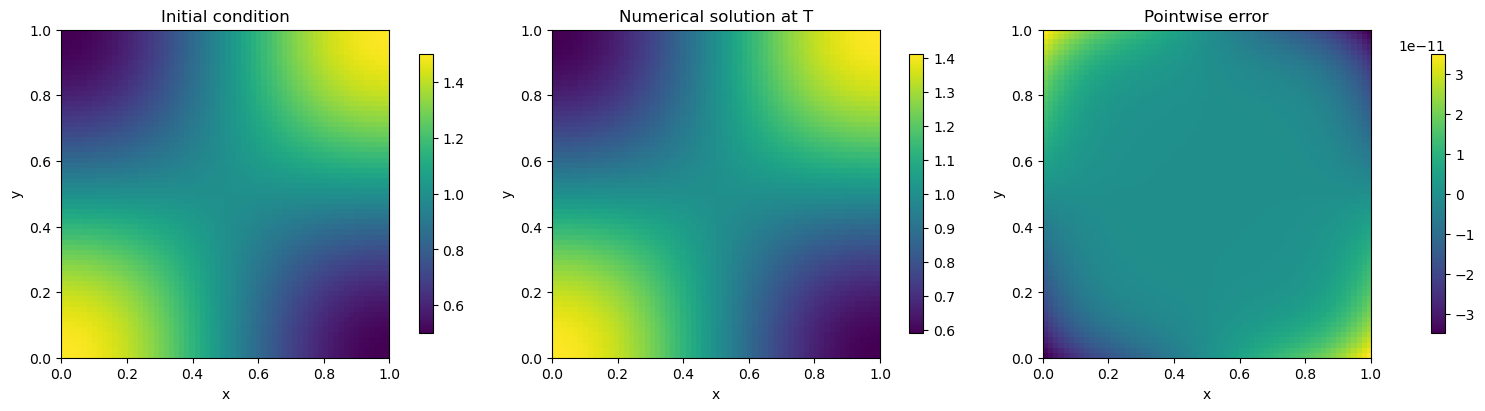

In [57]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axs[0].imshow(u0, origin="lower", extent=[0.0, Lx, 0.0, Ly])
axs[0].set_title("Initial condition")

im1 = axs[1].imshow(u_final, origin="lower", extent=[0.0, Lx, 0.0, Ly])
axs[1].set_title("Numerical solution at T")

im2 = axs[2].imshow(u_final - u_exact, origin="lower", extent=[0.0, Lx, 0.0, Ly])
axs[2].set_title("Pointwise error")

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax, im in zip(axs, (im0, im1, im2)):
    fig.colorbar(im, ax=ax, shrink=0.85)

plt.show()


## Inspect Diagnostic Histories

The next cell plots the sampled mass error and boundary-flux maxima during the
run. For this example both quantities should remain near machine precision.


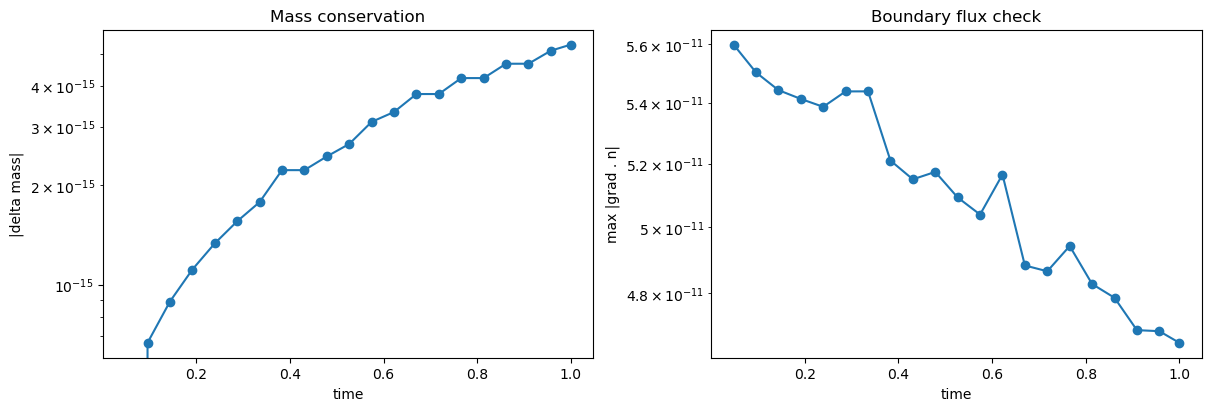

In [58]:
times = np.array([entry["time"] for entry in snapshots])
mass_errors = np.array([entry["mass_error"] for entry in snapshots])
max_fluxes = np.array([entry["max_flux"] for entry in snapshots])

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axs[0].plot(times, mass_errors, marker="o")
axs[0].set_title("Mass conservation")
axs[0].set_xlabel("time")
axs[0].set_ylabel("|delta mass|")
axs[0].set_yscale("log")

axs[1].plot(times, max_fluxes, marker="o")
axs[1].set_title("Boundary flux check")
axs[1].set_xlabel("time")
axs[1].set_ylabel("max |grad . n|")
axs[1].set_yscale("log")

plt.show()
